In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [2]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')
mass = penguins.dropna(subset=['body_mass_g', 'species'])

adelie    = mass.loc[mass['species'] == 'Adelie',    'body_mass_g']
chinstrap = mass.loc[mass['species'] == 'Chinstrap', 'body_mass_g']

print("Adelie    n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(adelie),    adelie.mean(),    adelie.std(ddof=1)))
print("Chinstrap n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(chinstrap), chinstrap.mean(), chinstrap.std(ddof=1)))

diff_g = adelie.mean() - chinstrap.mean()
print("\n두 종의 평균 차이: %.1f g  (Adelie 몸무게의 약 %.1f%%)" % (diff_g, abs(diff_g) / adelie.mean() * 100))

Adelie    n=151   평균 3700.7 g   표준편차 458.6 g
Chinstrap n= 68   평균 3733.1 g   표준편차 384.3 g

두 종의 평균 차이: -32.4 g  (Adelie 몸무게의 약 0.9%)


In [3]:
# 문제 2 · 이표본 t-검정 (Welch's t-test, 5-6장 실습과 동일)

t_stat, p_value = stats.ttest_ind(adelie, chinstrap, equal_var=False)

print(f"t-통계량 : {t_stat:.4f}")
print(f"p-값     : {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n결론: p-값({p_value:.4f}) < 유의수준({alpha})이므로, 귀무가설을 기각한다.")
    print("→ Adelie와 Chinstrap의 평균 몸무게에는 통계적으로 유의한 차이가 있다.")
else:
    print(f"\n결론: p-값({p_value:.4f}) ≥ 유의수준({alpha})이므로, 귀무가설을 기각하지 못한다.")
    print("→ Adelie와 Chinstrap의 평균 몸무게 차이는 통계적으로 유의하지 않다.")

t-통계량 : -0.5431
p-값     : 0.5879

결론: p-값(0.5879) ≥ 유의수준(0.05)이므로, 귀무가설을 기각하지 못한다.
→ Adelie와 Chinstrap의 평균 몸무게 차이는 통계적으로 유의하지 않다.


In [4]:
# Cohen's d 효과크기 함수 
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1)
    
    # 합동표준편차 (pooled standard deviation)
    pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    
    d = (np.mean(x) - np.mean(y)) / pooled_std
    return d

In [5]:
# adelie와 chinstrap의 효과크기 계산
d = cohen_d(adelie, chinstrap)

print(f"Cohen's d : {d:.4f}")

abs_d = abs(d)
if abs_d < 0.2:
    size = "매우 작음 (거의 무시할 수준)"
elif abs_d < 0.5:
    size = "작음 (small)"
elif abs_d < 0.8:
    size = "중간 (medium)"
else:
    size = "큼 (large)"

print(f"효과크기 판정 : {size}")
print(f"\n※ Cohen의 관례적 기준 → 0.2: 작음 / 0.5: 중간 / 0.8: 큼")

Cohen's d : -0.0742
효과크기 판정 : 매우 작음 (거의 무시할 수준)

※ Cohen의 관례적 기준 → 0.2: 작음 / 0.5: 중간 / 0.8: 큼


In [6]:
# 문제 4 · n에 따른 시뮬레이션
import numpy as np
import pandas as pd
from scipy import stats

# 모집단 참값 설정
MU_A, MU_C = adelie.mean(), chinstrap.mean()
SIGMA = np.sqrt(((len(adelie)-1)*adelie.std(ddof=1)**2 + (len(chinstrap)-1)*chinstrap.std(ddof=1)**2)
                / (len(adelie) + len(chinstrap) - 2))

rng = np.random.default_rng(7)

n_list = [30, 150, 1000, 5000, 20000]
n_sim = 400

results = []
for n in n_list:
    p_values = []
    d_values = []
    for _ in range(n_sim):
        sample_a = rng.normal(MU_A, SIGMA, n)
        sample_c = rng.normal(MU_C, SIGMA, n)
        
        t_stat, p_val = stats.ttest_ind(sample_a, sample_c, equal_var=False)
        d = cohen_d(sample_a, sample_c)
        
        p_values.append(p_val)
        d_values.append(d)
    
    p_values = np.array(p_values)
    d_values = np.array(d_values)
    
    results.append({
        'n': n,
        'p-값 중위수': np.median(p_values),
        'p<0.05 비율(%)': (p_values < 0.05).mean() * 100,
        "Cohen's d 평균": d_values.mean()
    })

df_result = pd.DataFrame(results)
print(df_result.to_string(index=False))

    n      p-값 중위수  p<0.05 비율(%)  Cohen's d 평균
   30 4.668554e-01          5.75     -0.080738
  150 4.421454e-01          9.50     -0.068576
 1000 8.407341e-02         39.25     -0.075479
 5000 1.578511e-04         95.50     -0.074863
20000 1.312323e-13        100.00     -0.074020


> 효과크기는 그대로 인데 표본크기가 커질수록 p값만 점점 낮아져 통계적 의미가 있는것처럼 보여진다

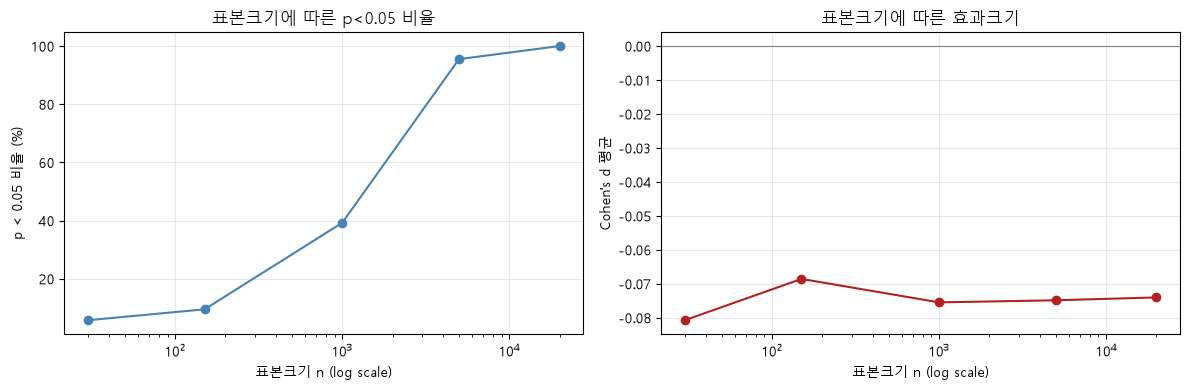

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: n에 따른 p<0.05 비율
ax[0].plot(df_result['n'], df_result['p<0.05 비율(%)'], marker='o', color='steelblue')
ax[0].set_xscale('log')
ax[0].set_xlabel('표본크기 n (log scale)')
ax[0].set_ylabel('p < 0.05 비율 (%)')
ax[0].set_title('표본크기에 따른 p<0.05 비율')
ax[0].grid(True, alpha=0.3)

# 오른쪽: n에 따른 Cohen's d 평균
ax[1].plot(df_result['n'], df_result["Cohen's d 평균"], marker='o', color='firebrick')
ax[1].set_xscale('log')
ax[1].set_xlabel('표본크기 n (log scale)')
ax[1].set_ylabel("Cohen's d 평균")
ax[1].set_title('표본크기에 따른 효과크기')
ax[1].axhline(0, color='gray', linewidth=0.8)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

▸
Q1에서 두 종의 몸무게는 통계적으로 유의한 차이가 없었습니다. 그런데 Q3에서 n=5,000일 때는 95% 이상 유의하게 나왔습니다. 같은 32g인데 결론이 갈린 이유는 무엇인가요?
  - 실제 데이터에서는 표본이 작아서 표준오차가 컸지만 크기가 5000이상이 되면 표준오차가 줄면서 똑같은 32g차이여도 이건 우연이 아니다 라고
  판단할 만큼 통계적 근거가 쌓인다. 그 차이를 감지하는 검정력이 표본 크기에 따라 달라진 것이 이유이다.

▸
Q3의 표에서 n이 커질 때 p-값은 어떻게 변했나요? Cohen's d는 어떻게 변했나요? 이 대비가 뜻하는 바를 한 문장으로 정리해 보세요.
  - 표본이 커질수록 p-값은 급격히 작아져 검정력이 100%까지 치솟았지만, 효과크기는 -0.07~-0.08 근처에서 거의 변하지 않았다. 
  즉, 표본 크기를 키우면 아주 작은 차이도 통계적으로 유의하게 잡아낼 수는 있지만, 그 차이 자체의 실질적 크기는 커지지 않는다.

▸
"통계적으로 유의하다"와 "실질적으로 의미 있다"는 같은 말인가요? 펭귄 32g을 예로 설명해 보세요.
  - 표본 크기 5,000이상부터 p값이 유의수준보다 낮을 확률이 95%로 귀무가설을 기각할 근거가 있다, 통계적으로 유의하다라고 할 수 있지만
  효과크기는 거의 모든 표본 크기에서 매우 낮음을 유지하고 있다. 
  즉 통계적으로 유의하다는 몸무게의 평균 차이는 우연이 아니다를 뜻하지만
  그것이 "그래서 몸무게 32g차이가 의미가 있는 차이다"라는 말은 아니다 - 실제로 32g은 성체 펭귄 몸무게의 0.9% 밖에 되지 않기 때문에 거의 무시해도 되는 수준이다.

▸
A/B 테스트에서 버튼 색을 바꿨더니 클릭률이 0.1%p 올랐고 p-값은 0.001이었습니다. 이 결과만으로 버튼을 바꿔야 한다고 말할 수 있을까요?
  - 통계적으로는 p값이 0.05보다 한참 낮기 때문에 이 클릭률의 차이가 우연일 가능성이 낮다 라고 해석할 수 있지만
  이것이 실질적으로 의미있는지는 다른 얘기임
  1. A/B 테스트의 표본 크기는 보통 매우 큼 즉 표본 크기 때문에 p값이 낮게 나왔을 가능성을 배제할 수 없다.
  2. 이것이 실질적으로 의미가 있는지를 판단하기 위해서는 효과크기를 같이 봐야하며, 개발비용 대비 이득이 얼마나 되는지, 신뢰구간도 같이 보고 판단을 해야한다.

▸
논문이나 보고서에 p-값만 적는 것이 왜 부족한가요? 무엇을 함께 적어야 할까요?
  - 앞에서 살펴본 바와 같이 p값은 사용자의 임의대로 조절할 수가 있다.
  따라서 효과크기, 표본크기, 신뢰구간을 같이 제시해야 판단의 근거가 충분해진다.

In [8]:
analysis = TTestIndPower()   # 검정력 분석 도구

print("검정력 분석에 쓰이는 네 개의 값")
print("  ① 유의수준 alpha  — 제1종 오류를 허용하는 한계 (보통 0.05)")
print("  ② 검정력 power    — 1 - beta, 진짜 차이를 잡아낼 확률 (보통 0.80)")
print("  ③ 효과크기 d      — 검출하고자 하는 차이의 크기")
print("  ④ 표본크기 nobs1  — 집단당 표본 수")
print("\n→ 이 중 셋을 정하면 나머지 하나가 결정됩니다.")

검정력 분석에 쓰이는 네 개의 값
  ① 유의수준 alpha  — 제1종 오류를 허용하는 한계 (보통 0.05)
  ② 검정력 power    — 1 - beta, 진짜 차이를 잡아낼 확률 (보통 0.80)
  ③ 효과크기 d      — 검출하고자 하는 차이의 크기
  ④ 표본크기 nobs1  — 집단당 표본 수

→ 이 중 셋을 정하면 나머지 하나가 결정됩니다.


### 신약은 효과가 없다(H0)

|                        | H0를 기각함 (효과가 있다고 결론)  | H0를 기각 못함 (효과가 없다고 결론) |
|------------------------|---------------------------------|----------------------------------|
|실제로 효과가 없을 때     |    1종오류                       |   옳은결정(1-알파) |
|실제로 효과가 있을 때     |   옳은결정(1-베타)                        |  2종오류 |

제1종 오류(alpha)를 범하면 무엇을 잃나요?: 효과가 없는(귀무가설이 참)값이지만 있다고 해버림
제2종 오류(beta)를 범하면 무엇을 잃나요?: 효과가 있는(귀무가설이 거짓)값이지만 없다고 해버림
검정력(1-beta)을 한 문장으로 정의하면?: 실제로 효과가 있을때 그 효과를 통계적으로 유의하게 잡아낼 확률

In [ ]:
#TTestIndPower 클래스의 power() 메서드를 이용하면, 효과크기 d와 표본크기 n를 가지고 몇 번 반복했을때 몇%가 유의미하게 나올지 계산할 수 있다.

from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()
d = abs(cohen_d(adelie, chinstrap))   # 0.0742

rows = []
for n in n_list:
    theo_power = analysis.power(effect_size=d, nobs1=n, alpha=0.05, ratio=1)
    rows.append({'n': n, '이론적 검정력': round(theo_power, 4)})

df_power = pd.DataFrame(rows)

# 문제 1 Q3의 시뮬레이션 결과와 나란히 비교
comparison = df_result.merge(df_power, on='n')
comparison = comparison.rename(columns={'p<0.05 비율(%)': '시뮬레이션 비율(%)'})
print(comparison[['n', '시뮬레이션 비율(%)', '이론적 검정력']].to_string(index=False))

    n  시뮬레이션 비율(%)  이론적 검정력
   30         5.75   0.0592
  150         9.50   0.0982
 1000        39.25   0.3816
 5000        95.50   0.9599
20000       100.00   1.0000


In [21]:
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

effect_sizes = [0.074, 0.2, 0.5, 0.8]
labels = ['펭귄 실측값 (d≈0.074)', '작음 (0.2)', '중간 (0.5)', '큼 (0.8)']

rows = []
for d, lab in zip(effect_sizes, labels):
    n_needed = analysis.solve_power(effect_size=d, alpha=0.05, power=0.8)
    rows.append({
        '효과크기 라벨': lab,
        "Cohen's d": d,
        '집단당 필요 표본수': int(np.ceil(n_needed))
    })

df_sample_size = pd.DataFrame(rows)
print(df_sample_size.to_string(index=False))

         효과크기 라벨  Cohen's d  집단당 필요 표본수
펭귄 실측값 (d≈0.074)      0.074        2868
        작음 (0.2)      0.200         394
        중간 (0.5)      0.500          64
         큼 (0.8)      0.800          26


solve_power로 구한 필요 표본수: 63.77


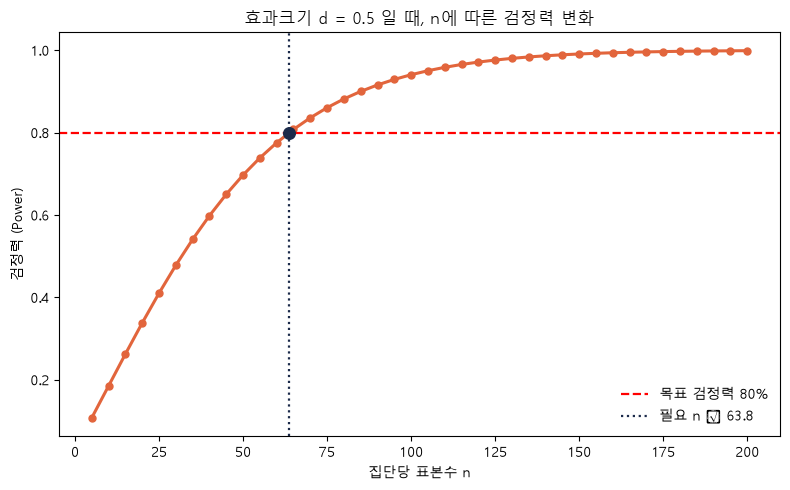

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()
d = 0.5
n_list = np.arange(5, 201, 5)
powers = [analysis.power(effect_size=d, nobs1=n, alpha=0.05, ratio=1) for n in n_list]

# Q3에서 구한 필요 표본수와 비교
n_needed = analysis.solve_power(effect_size=d, alpha=0.05, power=0.8)
print("solve_power로 구한 필요 표본수:", round(n_needed, 2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_list, powers, 'o-', color='#E2653C', lw=2.2, ms=5)
ax.axhline(0.8, color='red', linestyle='--', lw=1.6, label='목표 검정력 80%')
ax.axvline(n_needed, color='#1B2A4A', linestyle=':', lw=1.6, label=f'필요 n ≈ {n_needed:.1f}')
ax.scatter([n_needed], [0.8], color='#1B2A4A', s=70, zorder=5)

ax.set_xlabel('집단당 표본수 n')
ax.set_ylabel('검정력 (Power)')
ax.set_title(f"효과크기 d = {d} 일 때, n에 따른 검정력 변화")
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

▸
Q3에서 펭귄의 32g 차이(d ≈ 0.074)를 80% 검정력으로 잡으려면 집단당 몇 마리가 필요했나요? 팔머 기지 데이터는 전체가 344마리입니다. 이 연구는 애초에 가능했을까요?
  - 집단단 필요한 개체수가 2800마리에 육박했고 따라서 애초에 불가능한 연구였다.

▸
검정력이 낮은 연구에서 "유의한 차이가 없었다"는 결과가 나왔을 때, 우리는 무엇을 알 수 있고 무엇을 알 수 없나요? (7장 문제 4 Q5의 Adelie 수컷 회귀를 떠올려 보세요)
  - 이 표본수에서는 통계적으로 유의한 차이를 잡아내지 못했다 라는 것을 알 수 있다.
  하지만 검정력이 8%인건 진짜 차이가 있어도 92%의 확률로 못 찾아냈다는 말이기 때문에 
  이 실험이 사실 의미가 없었다 라는것을 시사한다

▸
실험을 시작하기 전에 표본수를 정해야 하는 이유는 무엇인가요? 데이터를 본 뒤에 정하면 무엇이 잘못될까요?
  - 시작전에 정하지 않으면 원하는 p값이 나올때까지 표본을 정하는 p해킹의 유혹에 빠지게 된다
  이러면 당연히 정상적인 결과가 나올 수 없다

▸
유의수준 alpha를 0.05에서 0.01로 낮추면 필요한 n은 늘어날까요, 줄어들까요? Q3의 코드를 고쳐 직접 계산해 확인해 보세요.
  - 필요한 표본크기는 더 늘어난다. 더 정확한 검정을 요구하기 때문

▸
"검출하고자 하는 효과크기를 얼마로 정할 것인가"는 통계 문제인가요, 도메인 문제인가요?
  - 도메인 문제임, 신약 연구라면 "혈압을 몇 mmHg 낮춰야 임상적으로 의미 있는가"는 의학적 판단 
  펭귄 연구라면 "32g 차이가 생태학적으로 중요한가, 아니면 그냥 개체 변이 수준인가"는 생물학적 판단
  마케팅 A/B 테스트라면 "클릭률 0.1%p가 사업적으로 의미 있는가"는 비즈니스 판단
  통계학자는 이정도 효과를 검출하기 위해 이정도는 필요하다를 알려줄 뿐, 실제 현장에서의 판단은 도메인별로 다르다.
  의미있는 효과크기를 먼저 정하고 표본크기를 정하는것이 순서

In [23]:
N_SIM = 1000     # 시뮬레이션 반복 횟수
SEED  = 777      # 난수 시드 — Q1~Q4에서 각각 이 값으로 시작하면 몇 번 재실행해도 같은 결과가 나옵니다

print("이번 문제의 전제")
print("  두 집단 A, B는 모두 N(0, 1)에서 나옵니다 → 진짜 차이는 정확히 0")
print("  즉 귀무가설이 '참'인 상황이며, 유의하다는 결론은 모두 제1종 오류입니다.")
print("  절차를 지켰다면 오류율은 유의수준 5% 근처여야 합니다.")
print("\n각 조건마다 %d번씩 반복해 '유의하다고 결론 내린 비율'을 셉니다." % N_SIM)

이번 문제의 전제
  두 집단 A, B는 모두 N(0, 1)에서 나옵니다 → 진짜 차이는 정확히 0
  즉 귀무가설이 '참'인 상황이며, 유의하다는 결론은 모두 제1종 오류입니다.
  절차를 지켰다면 오류율은 유의수준 5% 근처여야 합니다.

각 조건마다 1000번씩 반복해 '유의하다고 결론 내린 비율'을 셉니다.


In [24]:
import numpy as np
from scipy import stats

N_SIM = 1000
SEED  = 777

rng = np.random.default_rng(SEED)

sig_count = 0
for _ in range(N_SIM):
    A = rng.normal(0, 1, 20)
    B = rng.normal(0, 1, 20)
    _, p = stats.ttest_ind(A, B)
    if p < 0.05:
        sig_count += 1

rate = sig_count / N_SIM
print(f"유의하다고 결론 내린 횟수: {sig_count} / {N_SIM}")
print(f"제1종 오류율(비율): {rate:.4f}  ({rate*100:.2f}%)")

유의하다고 결론 내린 횟수: 49 / 1000
제1종 오류율(비율): 0.0490  (4.90%)


In [9]:
# 문제 4 · 데이터 준비 (2/2)
# 같은 학생 2,000명에게 '새 온라인 강의'를 배정하는 두 가지 방식
TRUE_EFFECT = 5.0                      # 강의의 진짜 효과: 기말고사 +5점
rng = np.random.default_rng(279)
n = 2000

pre_score   = rng.normal(60, 10, n)    # 교란요인 ① 사전 성적
study_hours = rng.normal(10,  3, n)    # 교란요인 ② 주당 학습시간

# 잠재결과 — 두 교란요인은 결과(기말고사 성적)에도 직접 영향을 줍니다
Y0 = 20 + 0.7 * pre_score + 0.8 * study_hours + rng.normal(0, 5, n)  # 강의를 안 들었을 때
Y1 = Y0 + TRUE_EFFECT                                                 # 강의를 들었을 때

# (A) 관찰연구 — 성적 좋고 열심인 학생이 스스로 신청 (선택 편향)
signup_logit = -0.6 + 0.10 * (pre_score - 60) + 0.20 * (study_hours - 10)
course_obs = rng.binomial(1, 1 / (1 + np.exp(-signup_logit)))

# (B) 무작위 통제 실험 — 동전을 던져 배정
course_rct = rng.binomial(1, 0.5, n)

df_obs = pd.DataFrame({'pre_score': pre_score, 'study_hours': study_hours,
                       'course': course_obs, 'final_score': np.where(course_obs == 1, Y1, Y0)})
df_rct = pd.DataFrame({'pre_score': pre_score, 'study_hours': study_hours,
                       'course': course_rct, 'final_score': np.where(course_rct == 1, Y1, Y0)})

print("참 효과(우리가 추정해야 하는 값): %.1f점\n" % TRUE_EFFECT)
print("관찰연구 df_obs — 수강생 %d명 (%.1f%%)" % (df_obs['course'].sum(), df_obs['course'].mean()*100))
print("RCT      df_rct — 수강생 %d명 (%.1f%%)" % (df_rct['course'].sum(), df_rct['course'].mean()*100))

참 효과(우리가 추정해야 하는 값): 5.0점

관찰연구 df_obs — 수강생 751명 (37.5%)
RCT      df_rct — 수강생 1012명 (50.6%)


In [25]:
import numpy as np
from scipy import stats

N_SIM = 1000
SEED  = 777

rng = np.random.default_rng(SEED)

def p_hacker():
    """20명으로 시작, p<0.05면 즉시 멈춤, 아니면 10명씩 추가해 최대 5번까지 재검정"""
    A = list(rng.normal(0, 1, 20))
    B = list(rng.normal(0, 1, 20))
    for attempt in range(5):
        _, p = stats.ttest_ind(A, B)
        if p < 0.05:
            return True   # "찾았다!" 하고 멈춤
        A.extend(rng.normal(0, 1, 10))
        B.extend(rng.normal(0, 1, 10))
    return False  # 5번 다 돌았는데도 못 찾음

sig_count = sum(p_hacker() for _ in range(N_SIM))
rate = sig_count / N_SIM

print(f"p-해커가 '찾았다'고 결론 내린 횟수: {sig_count} / {N_SIM}")
print(f"실제 오류율(비율): {rate:.4f}  ({rate*100:.2f}%)")

p-해커가 '찾았다'고 결론 내린 횟수: 135 / 1000
실제 오류율(비율): 0.1350  (13.50%)


In [26]:
import numpy as np
from scipy import stats

N_SIM = 1000
SEED  = 777
N_METRICS = 20

rng = np.random.default_rng(SEED)

def multi_metric_hacker():
    """아무 차이 없는 지표 20개를 각각 검정, 하나라도 유의하면 성공"""
    for _ in range(N_METRICS):
        A = rng.normal(0, 1, 20)
        B = rng.normal(0, 1, 20)
        _, p = stats.ttest_ind(A, B)
        if p < 0.05:
            return True
    return False

sig_count = sum(multi_metric_hacker() for _ in range(N_SIM))
sim_rate = sig_count / N_SIM
theory_rate = 1 - 0.95**N_METRICS

print(f"시뮬레이션 성공률 : {sim_rate:.4f}  ({sim_rate*100:.2f}%)")
print(f"이론값 1-0.95^20  : {theory_rate:.4f}  ({theory_rate*100:.2f}%)")

시뮬레이션 성공률 : 0.6480  (64.80%)
이론값 1-0.95^20  : 0.6415  (64.15%)


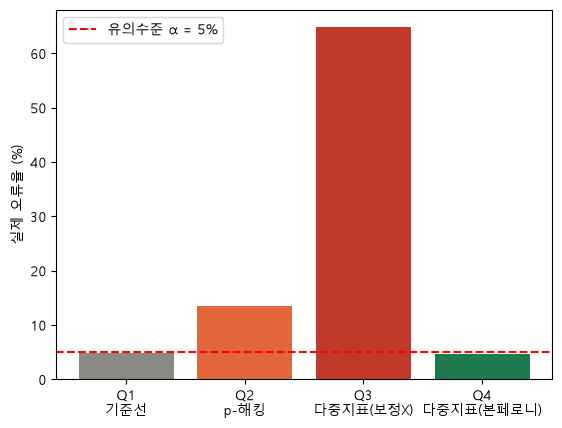

In [27]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

N_SIM = 1000
SEED  = 777
N_METRICS = 20

# Q1: 기준선
rng = np.random.default_rng(SEED)
sig = 0
for _ in range(N_SIM):
    A = rng.normal(0,1,20); B = rng.normal(0,1,20)
    _, p = stats.ttest_ind(A,B)
    if p < 0.05: sig += 1
rate_q1 = sig / N_SIM

# Q2: p-해킹 (표본 추가)
rng = np.random.default_rng(SEED)
def p_hacker():
    A = list(rng.normal(0,1,20)); B = list(rng.normal(0,1,20))
    for _ in range(5):
        _, p = stats.ttest_ind(A,B)
        if p < 0.05: return True
        A.extend(rng.normal(0,1,10)); B.extend(rng.normal(0,1,10))
    return False
rate_q2 = sum(p_hacker() for _ in range(N_SIM)) / N_SIM

# Q3 / Q4: 다중 지표 (alpha만 다르게)
def multi_metric_hacker(alpha):
    for _ in range(N_METRICS):
        A = rng.normal(0,1,20); B = rng.normal(0,1,20)
        _, p = stats.ttest_ind(A,B)
        if p < alpha: return True
    return False

rng = np.random.default_rng(SEED)
rate_q3 = sum(multi_metric_hacker(0.05) for _ in range(N_SIM)) / N_SIM   # 보정 없음

rng = np.random.default_rng(SEED)
alpha_corrected = 0.05 / N_METRICS                                        # ← 본페로니 보정
rate_q4 = sum(multi_metric_hacker(alpha_corrected) for _ in range(N_SIM)) / N_SIM

# 막대그래프
labels = ['Q1\n기준선', 'Q2\np-해킹', 'Q3\n다중지표(보정X)', 'Q4\n다중지표(본페로니)']
values = [rate_q1*100, rate_q2*100, rate_q3*100, rate_q4*100]

plt.bar(labels, values, color=['#8A8A85','#E2653C','#C0392B','#1E7A4C'])
plt.axhline(5, color='red', linestyle='--', label='유의수준 α = 5%')
plt.ylabel('실제 오류율 (%)')
plt.legend()
plt.show()

In [28]:
# 문제 4 · 데이터 준비 (1/2) — 실행만 하세요
# 펭귄 부리 데이터: 7장 문제 1에서 봤던 그 데이터입니다.
bills = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

print("분석에 사용할 데이터: %d 행\n" % len(bills))
print("종별 부리 평균 —— '종'이 두 변수 모두에 영향을 주고 있다는 단서")
print(bills.groupby('species')[['bill_length_mm', 'bill_depth_mm']].mean().round(2))

분석에 사용할 데이터: 342 행

종별 부리 평균 —— '종'이 두 변수 모두에 영향을 주고 있다는 단서
           bill_length_mm  bill_depth_mm
species                                 
Adelie              38.79          18.35
Chinstrap           48.83          18.42
Gentoo              47.50          14.98


In [29]:
import seaborn as sns
import statsmodels.formula.api as smf

penguins = sns.load_dataset('penguins')
bills = penguins.dropna(subset=['bill_depth_mm', 'bill_length_mm'])

model = smf.ols(formula='bill_depth_mm ~ bill_length_mm', data=bills).fit()

slope = model.params['bill_length_mm']
p_value = model.pvalues['bill_length_mm']

print(f"기울기 계수: {slope:.4f}")
print(f"p-값       : {p_value:.6f}")

기울기 계수: -0.0850
p-값       : 0.000011


In [30]:


penguins = sns.load_dataset('penguins')
bills = penguins.dropna(subset=['bill_depth_mm', 'bill_length_mm'])

rows = []
for species, group in bills.groupby('species'):
    model = smf.ols(formula='bill_depth_mm ~ bill_length_mm', data=group).fit()
    slope = model.params['bill_length_mm']
    p_value = model.pvalues['bill_length_mm']
    rows.append({
        '종': species,
        'n': len(group),
        '기울기 계수': round(slope, 4),
        'p-값': round(p_value, 6)
    })

df_species = pd.DataFrame(rows)
print(df_species.to_string(index=False))

        종   n  기울기 계수      p-값
   Adelie 151  0.1788 0.000001
Chinstrap  68  0.2222 0.000000
   Gentoo 123  0.2048 0.000000


In [31]:
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf

penguins = sns.load_dataset('penguins')
bills = penguins.dropna(subset=['bill_depth_mm', 'bill_length_mm', 'species'])

# Q1: 종 무시하고 단순회귀
m1 = smf.ols(formula='bill_depth_mm ~ bill_length_mm', data=bills).fit()

# Q3: 종을 통제변수로 함께 넣은 다중회귀
m2 = smf.ols(formula='bill_depth_mm ~ bill_length_mm + C(species)', data=bills).fit()

compare = pd.DataFrame({
    '모형': ['Q1: 종 무시', 'Q3: 종 통제'],
    '기울기(bill_length_mm)': [round(m1.params['bill_length_mm'],4), round(m2.params['bill_length_mm'],4)],
    'p-값': [f"{m1.pvalues['bill_length_mm']:.2e}", f"{m2.pvalues['bill_length_mm']:.2e}"],
    'R²': [round(m1.rsquared,4), round(m2.rsquared,4)]
})
print(compare.to_string(index=False))

      모형  기울기(bill_length_mm)      p-값     R²
Q1: 종 무시              -0.0850 1.12e-05 0.0552
Q3: 종 통제               0.1999 8.66e-26 0.7690


In [10]:
print("관찰연구 데이터 df_obs: %d행" % len(df_obs))
print("  수강생 %d명 / 비수강생 %d명" % ((df_obs['course']==1).sum(), (df_obs['course']==0).sum()))
print("  단순 평균 비교(문제 4 Q4): %+.2f점" % (
    df_obs.loc[df_obs['course']==1, 'final_score'].mean()
    - df_obs.loc[df_obs['course']==0, 'final_score'].mean()))
print("  우리가 되찾아야 하는 참 효과: %+.1f점" % TRUE_EFFECT)

관찰연구 데이터 df_obs: 2000행
  수강생 751명 / 비수강생 1249명
  단순 평균 비교(문제 4 Q4): +11.34점
  우리가 되찾아야 하는 참 효과: +5.0점


In [11]:
# 문제 5 · 데이터 준비 (2/2) — 실행만 하세요
# 서울(실험군) / 부산(통제군)의 1인당 월 데이터 사용량(GB), 2020~2025년
POLICY_YEAR = 2024        # 서울시가 무료 공공 와이파이를 도입한 해
TRUE_DID    = 4.0         # 정책의 진짜 효과: +4 GB
rng = np.random.default_rng(2024)

records = []
for city, baseline, is_seoul in [('서울', 15.0, 1), ('부산', 10.0, 0)]:
    for person in range(300):
        person_effect = rng.normal(0, 2.0)                  # 사람마다 타고난 사용량 차이
        for year in range(2020, 2026):
            time_trend = 1.5 * (year - 2020)                # 두 도시에 똑같이 작용하는 시간 추세
            policy = TRUE_DID if (is_seoul and year >= POLICY_YEAR) else 0.0
            records.append((city, is_seoul, person + is_seoul * 300, year,
                            baseline + person_effect + time_trend + policy + rng.normal(0, 1.0)))

panel = pd.DataFrame(records, columns=['city', 'is_seoul', 'person_id', 'year', 'data_usage'])

print("패널 데이터: %d행 (도시 2 × 300명 × 6년)" % len(panel))
print("정책 시행: %d년, 서울만  /  참 효과: +%.1f GB\n" % (POLICY_YEAR, TRUE_DID))
print(panel.groupby(['year', 'city'])['data_usage'].mean().unstack().round(2))

패널 데이터: 3600행 (도시 2 × 300명 × 6년)
정책 시행: 2024년, 서울만  /  참 효과: +4.0 GB

city     부산     서울
year              
2020  10.16  14.69
2021  11.54  16.27
2022  13.08  17.71
2023  14.60  19.22
2024  16.11  24.74
2025  17.59  26.36


city     부산     서울
year              
2020  10.16  14.69
2021  11.54  16.27
2022  13.08  17.71
2023  14.60  19.22

연도별 격차 (서울 - 부산):
year
2020    4.53
2021    4.73
2022    4.63
2023    4.63
dtype: float64


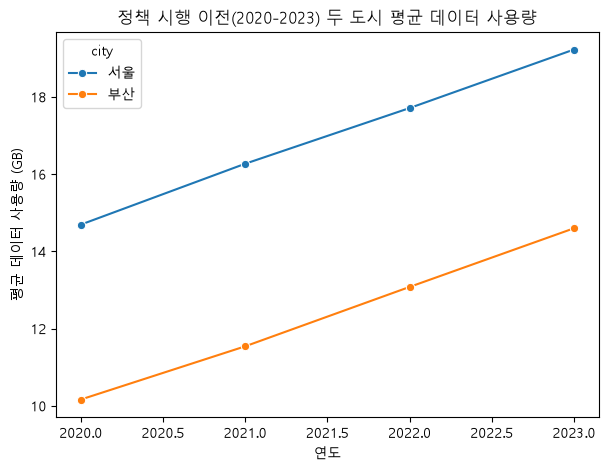

In [12]:
#문제 5 Q4- 평행추세 가정확인 데이터
# 1. 정책 시행 이전(2020~2023) 데이터만 자르기
pre_policy = panel[panel['year'] < POLICY_YEAR]

# 2. 연도별 두 도시 평균 사용량
pre_means = pre_policy.groupby(['year', 'city'])['data_usage'].mean().unstack()
print(pre_means.round(2))

# 3. 격차(서울 - 부산) 계산 및 출력
gap = pre_means['서울'] - pre_means['부산']
print("\n연도별 격차 (서울 - 부산):")
print(gap.round(2))

# 4. 꺾은선 그래프
plt.figure(figsize=(7, 5))
sns.lineplot(data=pre_policy, x='year', y='data_usage', hue='city', marker='o', errorbar=None)
plt.title('정책 시행 이전(2020-2023) 두 도시 평균 데이터 사용량')
plt.xlabel('연도')
plt.ylabel('평균 데이터 사용량 (GB)')
plt.show()

In [13]:
# 문제5 Q5- DiD 회귀분석
import statsmodels.formula.api as smf

# 정책 직전(2023)/직후(2024) 해만 추출
did_2x2 = panel[panel['year'].isin([2023, 2024])].copy()
did_2x2['is_post'] = (did_2x2['year'] == 2024).astype(int)

# 2x2 DiD 회귀
model = smf.ols('data_usage ~ is_seoul * is_post', data=did_2x2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             data_usage   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     1230.
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:23:02   Log-Likelihood:                -2655.2
No. Observations:                1200   AIC:                             5318.
Df Residuals:                    1196   BIC:                             5339.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           14.5950      0.128  

### 계수 세 개의 의미
  - is_seoul         의 의미: 정책 시행 전(2023년) 기준, 서울과 부산의 원래 격차 (도시 고유의 기저 차이)
  - is_post          의 의미: 서울/부산 구분 없이, 2023 → 2024년 사이 공통적으로 오른 사용량 (시간에 따른 자연 증가분)
  - is_seoul:is_post 의 의미: 서울이 2024년에 "추가로 더" 오른 만큼 → 정책의 순수 효과 (DiD 추정치)

In [14]:
#문제 5 Q6- 추정치 의심
# 위약(placebo) 검정: 정책 없던 구간 2022 vs 2023
placebo = panel[panel['year'].isin([2022, 2023])].copy()
placebo['is_post'] = (placebo['year'] == 2023).astype(int)   # 2023년이면 1

model_placebo = smf.ols('data_usage ~ is_seoul * is_post', data=placebo).fit()
print(model_placebo.summary())

print("\n상호작용항 계수:", model_placebo.params['is_seoul:is_post'])
print("상호작용항 p-값 :", model_placebo.pvalues['is_seoul:is_post'])

                            OLS Regression Results                            
Dep. Variable:             data_usage   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     491.1
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          6.42e-208
Time:                        21:23:02   Log-Likelihood:                -2645.9
No. Observations:                1200   AIC:                             5300.
Df Residuals:                    1196   BIC:                             5320.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           13.0765      0.127  

In [15]:
# DiD 보고 문장 (추정값 + 사용한 방법 + 평행추세 확인 + 플라시보 검정 결과):
#
# "이중차분법(DiD)을 이용해 서울시 공공 와이파이 정책의 효과를 추정한 결과,
#  정책은 1인당 월 데이터 사용량을 약 4.01GB 증가시킨 것으로 나타났다(p<0.001, 95% CI [3.51, 4.51]).
#  이 추정은 정책 시행 이전(2020~2023) 서울-부산의 사용량 격차가 4.5~4.7GB로 안정적으로 유지되어
#  평행추세 가정이 충족됨을 확인한 뒤 도출되었으며, 정책이 없었던 구간(2022 vs 2023)에
#  동일한 분석을 적용한 위약 검정에서 효과가 0에 가깝고 유의하지 않게 나와(계수 -0.003, p=0.990)
#  추정치의 신뢰성이 뒷받침되었다."

▸
Q4에서 정책 이전 4년간 두 도시의 격차는 거의 일정했습니다. 이것이 DiD의 어떤 가정을 지지하나요? 만약 이전부터 격차가 벌어지고 있었다면 Q5의 계수를 어떻게 읽어야 할까요?
  - 정책 시행 이전에는 평행추세가정을 근거함. 즉 두 지역은 정책 시행 이전에 차이가 없었다라는것을 보여주는것이고
  만약 이전부터 격차가 벌어지고 있었다면 정책 효과 + 원래 있던 차이 가 합쳐진 것이니 과대포장되었을 가능성을 시사함

▸
Q5의 상호작용항이 왜 정책효과인가요? 네 개 평균값을 직접 계산해 (A₂ − A₁) − (B₂ − B₁)과 일치하는지 확인해 보세요.
  - A는 서울의 변화량 B는 부산의 변화량을 뜻하고 A에는 정책+시간 변화, B에는 시간변화만 있으므로 둘을 빼면 A의 정책의 효과만 남게된다.

▸
Q6의 플라시보 검정이 만약 유의하게 나왔다면, 우리는 무엇을 의심해야 하나요?
  - 
  1. 평행추세가정 위반 : 두 도시가 애초에 정책과 무관하게 다른 속도로 변하고 있었다
  2. 다른 혼재요인의 가능성 : 그 시기에 서울에서만 벌어진 다른 사건(요금제 변경, 인프라 투자 등)이 있었을 가능성
  3. Q5 추정치에 대한 신뢰 저하 — 위약 검정이 실패하면, 진짜 정책 구간에서 나온 4.01GB도 "정책 때문"이라고 확신하기 어려워짐


▸
PSM과 DiD는 각각 어떤 상황에 쓰는 도구인가요? 두 방법의 데이터 요구조건 (단면 데이터 vs 패널 데이터)은 어떻게 다른가요?

In [16]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

SEOUL_EFFECT = 4.0

def make_panel(busan_effect=4.0, seoul_decay=None, n_person=300, seed=2027):
    """
    2020~2027 패널 생성.
      busan_effect : 2027년 부산 정책의 '참' 효과
      seoul_decay  : 서울 2024 정책의 잔존효과 감쇠율.
                     None → 2025년에 완전 소멸 (정책 종료)
                     1.0  → 크기 그대로 영구 지속
                     0.7  → 해마다 70%로 줄며 서서히 소멸
    """
    rng = np.random.default_rng(seed)
    rows = []
    for city, baseline, is_seoul in [('서울', 15.0, 1), ('부산', 10.0, 0)]:
        for p in range(n_person):
            person_effect = rng.normal(0, 2.0)
            for year in range(2020, 2028):
                trend = 1.5 * (year - 2020)
                policy = 0.0
                if is_seoul:
                    if year == 2024:
                        policy = SEOUL_EFFECT
                    elif year >= 2025 and seoul_decay is not None:
                        policy = SEOUL_EFFECT * (seoul_decay ** (year - 2024))
                elif year >= 2027:
                    policy = busan_effect
                rows.append((city, is_seoul, p + is_seoul * n_person, year,
                             baseline + person_effect + trend + policy + rng.normal(0, 1.0)))
    df = pd.DataFrame(rows, columns=['city','is_seoul','person_id','year','data_usage'])
    df['is_busan'] = 1 - df['is_seoul']
    return df


def did_2x2(df, pre, post, treat='is_busan'):
    """pre/post 2개 연도로 2x2 DiD. person_id 클러스터 표준오차."""
    d = df[df['year'].isin([pre, post])].copy()
    d['is_post'] = (d['year'] == post).astype(int)
    m = smf.ols(f'data_usage ~ {treat} * is_post', data=d).fit(
        cov_type='cluster', cov_kwds={'groups': d['person_id']})
    t = f'{treat}:is_post'
    lo, hi = m.conf_int().loc[t]
    return dict(coef=m.params[t], se=m.bse[t], p=m.pvalues[t], lo=lo, hi=hi)


def check_parallel(df, years):
    means = df[df['year'].isin(years)].groupby(['year','city'])['data_usage'].mean().unstack()
    return means.round(2), (means['부산'] - means['서울']).round(3)


def run_scenario(busan_effect=4.0, seoul_decay=None, seed=2027, verbose=True):
    """평행추세 확인 → 위약검정 → 본 DiD 를 한 번에."""
    df = make_panel(busan_effect, seoul_decay, seed=seed)
    means, gap = check_parallel(df, [2025, 2026])
    placebo = did_2x2(df, 2025, 2026)
    main    = did_2x2(df, 2026, 2027)
    if verbose:
        print(f"[참 효과 {busan_effect} / 서울 감쇠 {seoul_decay}]")
        print(means.to_string())
        print(f"  2025~26 격차(부산-서울): {gap.tolist()}")
        print(f"  위약검정 2025v2026 : coef={placebo['coef']:+.3f}  p={placebo['p']:.3f}")
        print(f"  본 DiD  2026v2027 : coef={main['coef']:+.3f}  "
              f"95%CI[{main['lo']:.2f}, {main['hi']:.2f}]  p={main['p']:.2g}")
        print(f"  추정오차 = {main['coef'] - busan_effect:+.3f}\n")
    return dict(gap=gap, placebo=placebo, main=main, truth=busan_effect)


# 사용 예
run_scenario(4.0,  None)   # 정상: 서울 정책 완전 종료
run_scenario(2.67, None)   # 부산 효과가 실제로 더 작은 경우
run_scenario(4.0,  0.7)    # 오염: 서울 잔존효과가 서서히 감소 중

[참 효과 4.0 / 서울 감쇠 None]
city     부산     서울
year              
2025  17.65  22.50
2026  19.11  23.98
  2025~26 격차(부산-서울): [-4.851, -4.874]
  위약검정 2025v2026 : coef=-0.024  p=0.837
  본 DiD  2026v2027 : coef=+3.809  95%CI[3.58, 4.04]  p=1.6e-231
  추정오차 = -0.191

[참 효과 2.67 / 서울 감쇠 None]
city     부산     서울
year              
2025  17.65  22.50
2026  19.11  23.98
  2025~26 격차(부산-서울): [-4.851, -4.874]
  위약검정 2025v2026 : coef=-0.024  p=0.837
  본 DiD  2026v2027 : coef=+2.479  95%CI[2.25, 2.71]  p=3.2e-99
  추정오차 = -0.191

[참 효과 4.0 / 서울 감쇠 0.7]
city     부산     서울
year              
2025  17.65  25.30
2026  19.11  25.94
  2025~26 격차(부산-서울): [-7.651, -6.834]
  위약검정 2025v2026 : coef=+0.816  p=0.000
  본 DiD  2026v2027 : coef=+4.397  95%CI[4.17, 4.63]  p=7.9e-308
  추정오차 = +0.397



{'gap': year
 2025   -7.651
 2026   -6.834
 dtype: float64,
 'placebo': {'coef': np.float64(0.8162567061940424),
  'se': np.float64(0.11516059549145446),
  'p': np.float64(1.3607758254294325e-12),
  'lo': 0.590546086592606,
  'hi': 1.041967325795479},
 'main': {'coef': np.float64(4.396516436110968),
  'se': np.float64(0.11722732693367939),
  'p': np.float64(7.869252924276341e-308),
  'lo': 4.166755097317054,
  'hi': 4.626277774904882},
 'truth': 4.0}